# Classificação: Primeiros passos

Neste projeto, iremos analisar dados de uma campanha de marketing para aderência de investimentos. O intuito é usar as informações dos dados para prever se os clientes de um banco vão aplicar o dinheiro em um investimento ou não.

Essa previsão será feita utilizando machine learning e este notebook vai conter os passos para se obter um modelo capaz de realizar as previsões, desde a **leitura**, **análise exploratória**, **separação** e **transformação** dos dados, até o **ajuste**, **avaliação** e **comparação** de modelos de classificação.

# Análise exploratória

## Fazendo a leitura dos dados

Podemos realizar a leitura dos dados a partir da biblioteca `pandas`. Por conta disso, vamos realizar a importação da biblioteca com o comando `import pandas as pd`.

Como o arquivo de dados está no formato *csv*, vamos realizar a leitura com a função [`read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).

In [3]:
import pandas as pd

In [4]:
dados = pd.read_csv('marketing_investimento.csv')

In [5]:
dados

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos,aderencia_investimento
0,45,casado (a),superior,nao,242,nao,587,1,sim
1,42,casado (a),medio,nao,1289,nao,250,4,sim
2,23,solteiro (a),superior,nao,363,nao,16,18,nao
3,58,divorciado (a),superior,nao,1382,nao,700,1,sim
4,50,casado (a),medio,nao,3357,nao,239,4,sim
...,...,...,...,...,...,...,...,...,...
1263,52,solteiro (a),superior,nao,83,nao,1223,6,sim
1264,35,solteiro (a),superior,nao,5958,nao,215,1,sim
1265,30,solteiro (a),superior,nao,-477,sim,1532,2,sim
1266,42,casado (a),superior,nao,2187,nao,525,3,sim


Para criar modelos de classificação, precisamos utilizar dados de qualidade, sem inconsistências e sem dados faltantes. Vamos checar se existem dados nulos e o tipo dos dados de cada coluna na base de dados a partir do método [`info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html).

In [6]:
print(dados.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268 entries, 0 to 1267
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   idade                   1268 non-null   int64 
 1   estado_civil            1268 non-null   object
 2   escolaridade            1268 non-null   object
 3   inadimplencia           1268 non-null   object
 4   saldo                   1268 non-null   int64 
 5   fez_emprestimo          1268 non-null   object
 6   tempo_ult_contato       1268 non-null   int64 
 7   numero_contatos         1268 non-null   int64 
 8   aderencia_investimento  1268 non-null   object
dtypes: int64(4), object(5)
memory usage: 89.3+ KB
None


In [7]:
print(dados.describe())

             idade         saldo  tempo_ult_contato  numero_contatos
count  1268.000000   1268.000000        1268.000000      1268.000000
mean     41.376972   1443.426656         367.574921         2.715300
std      11.383805   2690.406767         347.969723         2.885642
min      19.000000  -1206.000000           5.000000         1.000000
25%      33.000000     91.250000         134.000000         1.000000
50%      39.000000    491.500000         251.000000         2.000000
75%      49.000000   1623.500000         488.250000         3.000000
max      87.000000  27069.000000        3025.000000        32.000000


In [8]:
import plotly.express as px

In [9]:
px.histogram(dados, x='aderencia_investimento', text_auto=True)

In [10]:
px.histogram(dados, x='estado_civil', text_auto=True, color='aderencia_investimento', barmode='group')

In [11]:
px.histogram(dados, x='escolaridade', text_auto=True, color='aderencia_investimento', barmode='group')

In [12]:
px.histogram(dados, x='inadimplencia', text_auto=True, color='aderencia_investimento', barmode='group')

In [13]:
px.histogram(dados, x='fez_emprestimo', text_auto=True, color='aderencia_investimento', barmode='group')

In [14]:
px.box(dados, x='idade', color='aderencia_investimento')

In [15]:
px.box(dados, x='saldo', color='aderencia_investimento')

In [16]:
px.box(dados, x='tempo_ult_contato', color='aderencia_investimento')

In [17]:
px.box(dados, x='numero_contatos', color='aderencia_investimento')

In [18]:
x = dados.drop('aderencia_investimento', axis=1)
y = dados['aderencia_investimento']

In [19]:
y

0       sim
1       sim
2       nao
3       sim
4       sim
       ... 
1263    sim
1264    sim
1265    sim
1266    sim
1267    sim
Name: aderencia_investimento, Length: 1268, dtype: object

In [20]:
x

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos
0,45,casado (a),superior,nao,242,nao,587,1
1,42,casado (a),medio,nao,1289,nao,250,4
2,23,solteiro (a),superior,nao,363,nao,16,18
3,58,divorciado (a),superior,nao,1382,nao,700,1
4,50,casado (a),medio,nao,3357,nao,239,4
...,...,...,...,...,...,...,...,...
1263,52,solteiro (a),superior,nao,83,nao,1223,6
1264,35,solteiro (a),superior,nao,5958,nao,215,1
1265,30,solteiro (a),superior,nao,-477,sim,1532,2
1266,42,casado (a),superior,nao,2187,nao,525,3


In [21]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [22]:
colunas = x.columns

In [23]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['estado_civil', 'escolaridade', 'inadimplencia', 'fez_emprestimo']
),
    remainder='passthrough',
    sparse_threshold=0

                                  )

In [24]:
x = one_hot.fit_transform(x)

In [25]:
one_hot.get_feature_names_out()

array(['onehotencoder__estado_civil_casado (a)',
       'onehotencoder__estado_civil_divorciado (a)',
       'onehotencoder__estado_civil_solteiro (a)',
       'onehotencoder__escolaridade_fundamental',
       'onehotencoder__escolaridade_medio',
       'onehotencoder__escolaridade_superior',
       'onehotencoder__inadimplencia_sim',
       'onehotencoder__fez_emprestimo_sim', 'remainder__idade',
       'remainder__saldo', 'remainder__tempo_ult_contato',
       'remainder__numero_contatos'], dtype=object)

In [26]:
pd.DataFrame(x,columns = one_hot.get_feature_names_out(colunas))

,onehotencoder__estado_civil_casado (a),onehotencoder__estado_civil_divorciado (a),onehotencoder__estado_civil_solteiro (a),onehotencoder__escolaridade_fundamental,onehotencoder__escolaridade_medio,onehotencoder__escolaridade_superior,onehotencoder__inadimplencia_sim,onehotencoder__fez_emprestimo_sim,remainder__idade,remainder__saldo,remainder__tempo_ult_contato,remainder__numero_contatos
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,45.0,242.0,587.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,42.0,1289.0,250.0,4.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,23.0,363.0,16.0,18.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,58.0,1382.0,700.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,50.0,3357.0,239.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1263,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,52.0,83.0,1223.0,6.0
1264,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,35.0,5958.0,215.0,1.0
1265,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,30.0,-477.0,1532.0,2.0
1266,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,42.0,2187.0,525.0,3.0


In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
label_encoder = LabelEncoder()

In [29]:
y = label_encoder.fit_transform(y)

In [30]:
y

array([1, 1, 0, ..., 1, 1, 1])

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
x_treino, x_teste, y_treino, y_teste =  train_test_split(x,y, stratify = y, random_state = 5)

In [33]:
from sklearn.dummy import DummyClassifier

In [34]:
dummy = DummyClassifier()
dummy.fit(x_treino, y_treino)
dummy.score(x_teste, y_teste)

0.6025236593059937

In [35]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
arvore = DecisionTreeClassifier(random_state=5)
arvore.fit(x_treino, y_treino)


DecisionTreeClassifier(random_state=5)

In [40]:
arvore.predict(x_teste)

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,

In [41]:
arvore.score(x_teste, y_teste)

0.6656151419558359

In [42]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [45]:
nome_colunas = ['casado (a)',
                'divorciado (a)',
                'solteiro (a)',
                'fundamental',
                'medio',
                'superior',
                'inadimplencia',
                'fez_emprestimo',
                'idade',
                'saldo',
                'tempo_ult_contato',
                'numero_contatos']

[Text(0.5428645412287793, 0.98, 'tempo_ult_contato <= 248.5\ngini = 0.478\nsamples = 951\nvalue = [575, 376]\nclass = não'),
 Text(0.2825005052546483, 0.94, 'idade <= 59.5\ngini = 0.278\nsamples = 480\nvalue = [400, 80]\nclass = não'),
 Text(0.4126825232417138, 0.96, 'True  '),
 Text(0.14947958771220696, 0.9, 'tempo_ult_contato <= 86.5\ngini = 0.253\nsamples = 458\nvalue = [390, 68]\nclass = não'),
 Text(0.05173807599029911, 0.86, 'divorciado (a) <= 0.5\ngini = 0.061\nsamples = 127\nvalue = [123, 4]\nclass = não'),
 Text(0.038803556992724336, 0.82, 'idade <= 34.5\ngini = 0.034\nsamples = 114\nvalue = [112, 2]\nclass = não'),
 Text(0.03233629749393695, 0.78, 'numero_contatos <= 3.5\ngini = 0.111\nsamples = 34\nvalue = [32, 2]\nclass = não'),
 Text(0.025869037995149554, 0.74, 'saldo <= 194.0\ngini = 0.18\nsamples = 20\nvalue = [18, 2]\nclass = não'),
 Text(0.019401778496362168, 0.7, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]\nclass = não'),
 Text(0.03233629749393695, 0.7, 'saldo <= 216.5\n

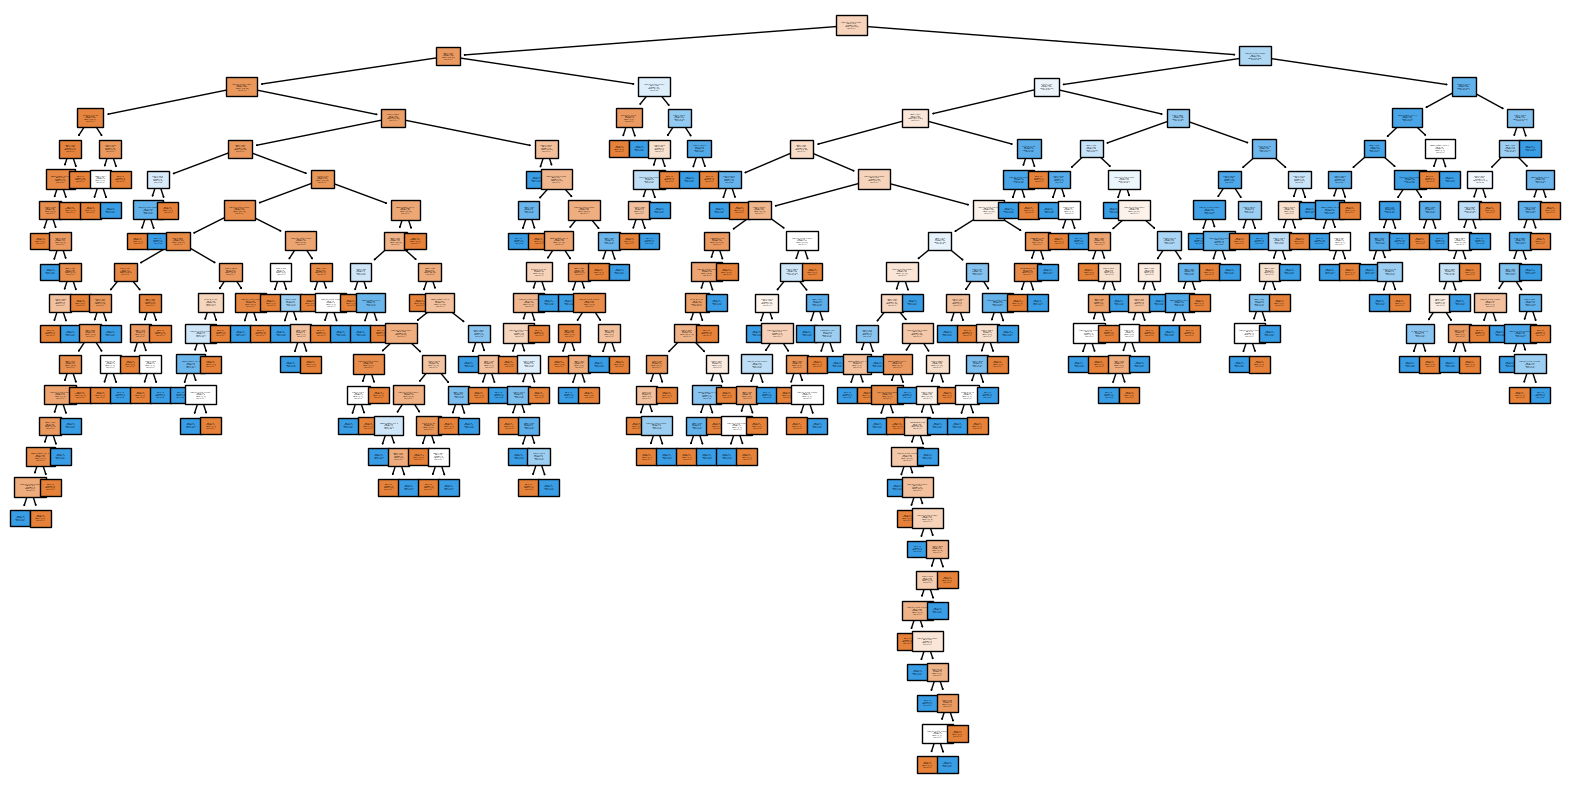

In [46]:
plt.figure(figsize =(20,10))
plot_tree(arvore, filled= True, feature_names = nome_colunas, class_names = ['não', 'sim'], fontsize=1)

In [47]:
arvore.score(x_treino, y_treino)

1.0

In [48]:
arvore = DecisionTreeClassifier(max_depth = 3, random_state=5)
arvore.fit(x_treino, y_treino)

DecisionTreeClassifier(max_depth=3, random_state=5)

In [49]:
arvore.predict(x_teste)

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,

In [50]:
arvore.score(x_teste, y_teste)

0.7160883280757098

In [51]:
arvore.score(x_treino, y_treino)

0.7613038906414301

[Text(0.5, 0.875, 'tempo_ult_contato <= 248.5\ngini = 0.478\nsamples = 951\nvalue = [575, 376]\nclass = não'),
 Text(0.25, 0.625, 'idade <= 59.5\ngini = 0.278\nsamples = 480\nvalue = [400, 80]\nclass = não'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'tempo_ult_contato <= 86.5\ngini = 0.253\nsamples = 458\nvalue = [390, 68]\nclass = não'),
 Text(0.0625, 0.125, 'gini = 0.061\nsamples = 127\nvalue = [123, 4]\nclass = não'),
 Text(0.1875, 0.125, 'gini = 0.312\nsamples = 331\nvalue = [267, 64]\nclass = não'),
 Text(0.375, 0.375, 'tempo_ult_contato <= 142.0\ngini = 0.496\nsamples = 22\nvalue = [10, 12]\nclass = sim'),
 Text(0.3125, 0.125, 'gini = 0.278\nsamples = 6\nvalue = [5, 1]\nclass = não'),
 Text(0.4375, 0.125, 'gini = 0.43\nsamples = 16\nvalue = [5, 11]\nclass = sim'),
 Text(0.75, 0.625, 'tempo_ult_contato <= 628.5\ngini = 0.467\nsamples = 471\nvalue = [175, 296]\nclass = sim'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'superior <= 0.5\ngini = 0.499\nsamples = 312\n

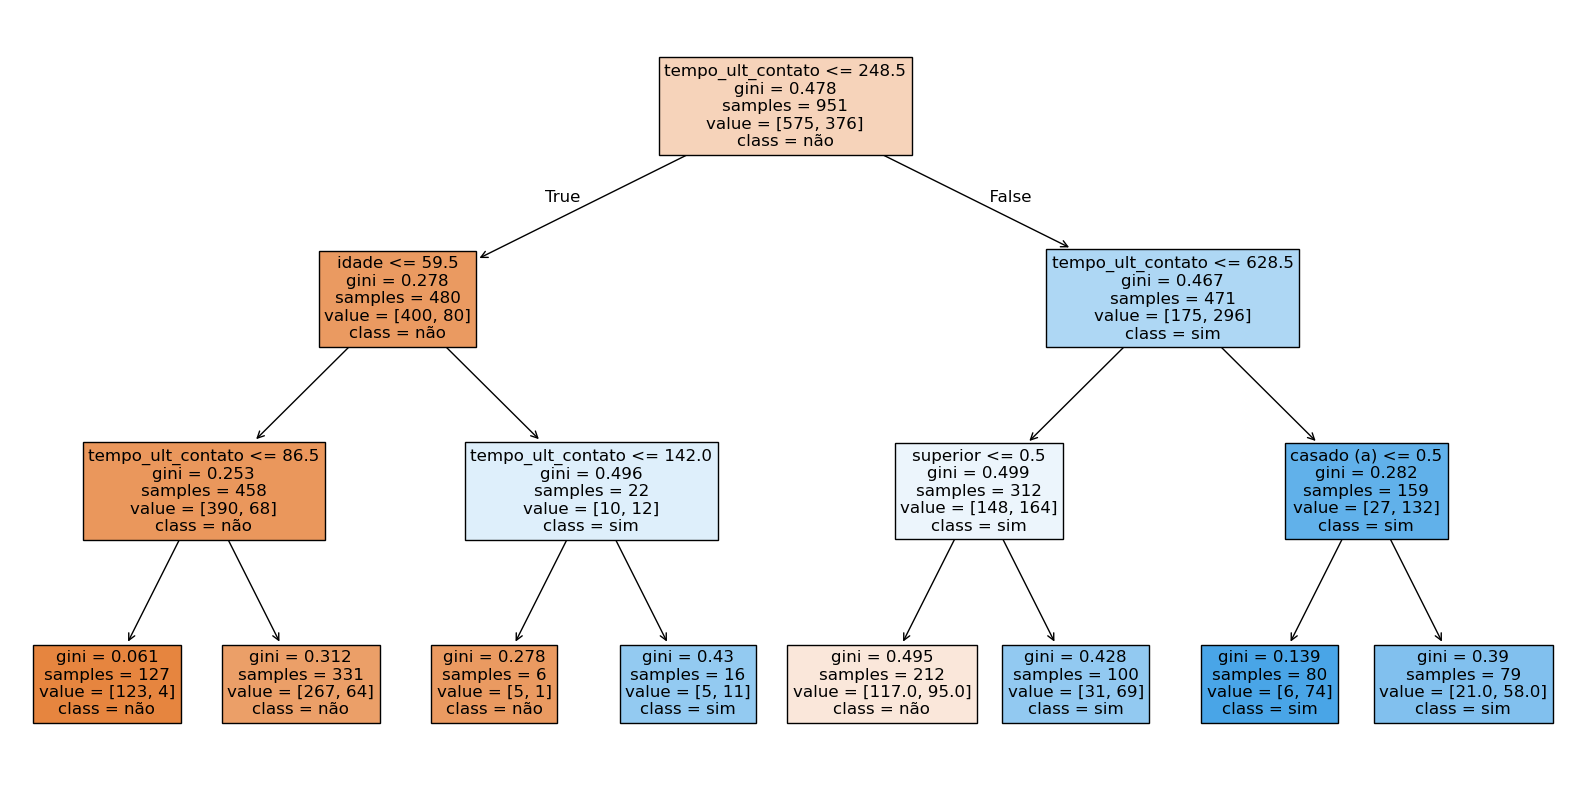

In [52]:
plt.figure(figsize=(20,10))
plot_tree(arvore, filled= True, feature_names = nome_colunas, class_names = ['não', 'sim'], fontsize=12)